<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Analysis</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Import Libraries</h3>
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from copy import copy

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.special import erf
from pathlib import Path
from numpy.fft import fft, ifft

from datetime import datetime
import json

#import ipywidgets as widgets
from IPython.display import display
from collections import defaultdict

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Load Data</h3>
</div>

In [28]:
base_dir = Path(r"/Volumes/hlab-nas/Data/DefectMsmts/Data/Convolution_Msmnts")
spd_run_numbers = [262,263,264,265,267,268,269,270,271,273]  # 198-199 inclusive
spd_runs = {}
for run_num in spd_run_numbers:
    matches = list(base_dir.glob(f"*_{run_num}"))
    if not matches:
        print(f"no folder found for run {run_num}")
        continue
    folder = matches[0]

    npz_path = folder / "data.npz"
    data = np.load(npz_path)

    metadata_path = folder / "metadata.json"
    with open(metadata_path) as f:
        metadata = json.load(f)

    spd_runs[run_num] = {
        "data": data,
        "metadata": metadata,
        "folder": folder,
    }
    print(f"loaded run {run_num}: {folder.name}")

loaded run 262: 20260721183421_262
loaded run 263: 20260721204525_263
loaded run 264: 20260721231110_264
loaded run 265: 20260722074017_265
loaded run 267: 20260722094353_267
loaded run 268: 20260722141406_268
loaded run 269: 20260722163411_269
loaded run 270: 20260722200433_270
loaded run 271: 20260723001353_271
loaded run 273: 20260723133544_273


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Analyze</h3>
</div>

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Plot Raw Data</h4>
</div>

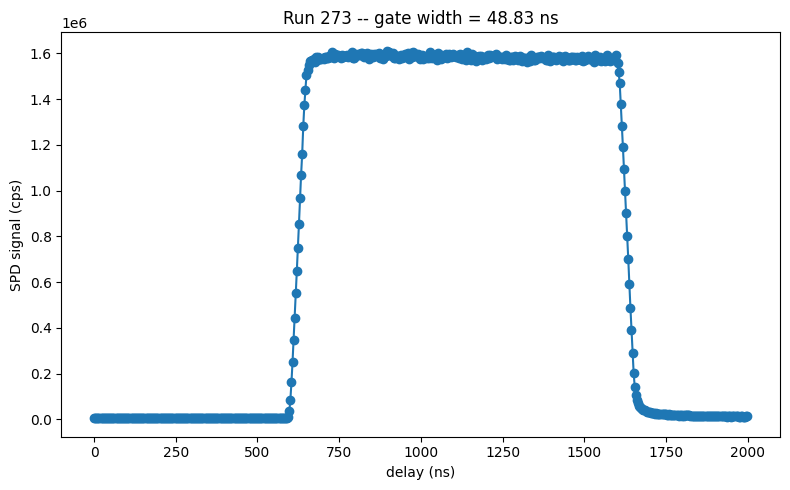

In [29]:
run_num = 273
t = spd_runs[run_num]["data"]["delays_ns"]
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
gate_width = spd_runs[run_num]["metadata"]["gate_width_tns"]

gate_width_s = gate_width * 1e-9
y = counts_mean / gate_width_s   # now genuinely cps, matching the original plot

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, y, 'o-')
ax.set_xlabel('delay (ns)')
ax.set_ylabel('SPD signal (cps)')
ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')
plt.tight_layout()
plt.show()

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Double Error Fit Function</h4>
</div>

In [5]:
def model_step_convolved(t, t0, rise_time, baseline, plateau, t_off, fall_time):
    """
    Model: a smooth rise (erf) up to plateau, then a smooth fall back down,
    THEN blurred by our known gate-width kernel -- same kernel as before.
    rise_time/fall_time control how gradual the underlying (pre-blur) edge is.
    """
    true_signal = baseline + (plateau - baseline) * 0.5 * (
        erf((t - t0) / rise_time) - erf((t - t_off) / fall_time)
    )
    blurred = np.convolve(true_signal, kernel, mode='same')
    return blurred

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Plot Fit</h4>
</div>

/Users/jereemurray/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


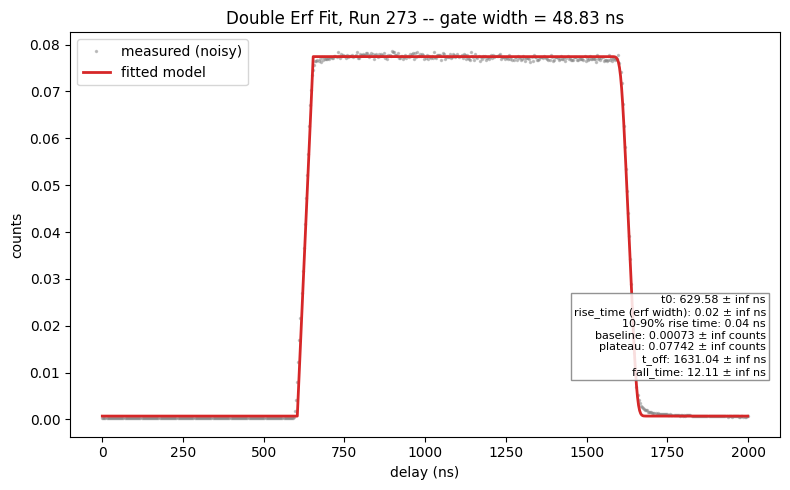

In [30]:
p0 = [
    t[len(t)//3],
    20,
    counts_mean[:20].mean(),
    counts_mean.max(),
    t[2*len(t)//3],
    20,
]

dt = np.median(np.diff(t))
kernel_len = max(1, int(round(gate_width / dt)))
kernel = np.ones(kernel_len) / kernel_len
popt, pcov = curve_fit(model_step_convolved, t, counts_mean, p0=p0)
perr = np.sqrt(np.diag(pcov))

fitted_curve = model_step_convolved(t, *popt)

t0_fit, rise_time_fit = popt[0], popt[1]
rise_10_90_erf = 2.563 * rise_time_fit

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, counts_mean, '.', color='gray', alpha=0.4, label='measured (noisy)', markersize=3)
ax.plot(t, fitted_curve, color='tab:red', label='fitted model', linewidth=2)
ax.legend(loc='upper left')
ax.set_xlabel('delay (ns)')
ax.set_ylabel('counts')
ax.set_title(f'Double Erf Fit, Run {run_num} -- gate width = {gate_width:.2f} ns')

stats_text = (f"t0: {popt[0]:.2f} ± {perr[0]:.2f} ns\n"
              f"rise_time (erf width): {popt[1]:.2f} ± {perr[1]:.2f} ns\n"
              f"10-90% rise time: {rise_10_90_erf:.2f} ns\n"
              f"baseline: {popt[2]:.5f} ± {perr[2]:.5f} counts\n"
              f"plateau: {popt[3]:.5f} ± {perr[3]:.5f} counts\n"
              f"t_off: {popt[4]:.2f} ± {perr[4]:.2f} ns\n"
              f"fall_time: {popt[5]:.2f} ± {perr[5]:.2f} ns")
ax.text(0.98, 0.35, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=8,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, pad=2))

plt.tight_layout()
plt.show()

Save

In [31]:
save_dir = spd_runs[run_num]["folder"]
fig.savefig(save_dir / "SNR.png", dpi=150, bbox_inches='tight')
print(f"Saved to: {save_dir / 'Erf_Fit.png'}")

Saved to: /Volumes/hlab-nas/Data/DefectMsmts/Data/Convolution_Msmnts/20260723133544_273/Erf_Fit.png


<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Noise Analysis</h5>
</div>

In [8]:
def find_settled_regions(t, y, buffer_ns_rise=60, buffer_ns_fall=400, smooth_window_ns=20):
    t = np.asarray(t)
    y = np.asarray(y)
    dt = np.median(np.diff(t))
    smooth_pts = max(1, int(round(smooth_window_ns / dt)))

    kernel = np.ones(smooth_pts) / smooth_pts
    y_smooth = np.convolve(y, kernel, mode='same')

    thresh = (y_smooth.max() + y_smooth.min()) / 2
    above = y_smooth > thresh
    high_idxs = np.where(above)[0]
    rise_idx = high_idxs[0]
    fall_idx = high_idxs[-1]

    buffer_pts_rise = int(round(buffer_ns_rise / dt))
    buffer_pts_fall = int(round(buffer_ns_fall / dt))

    plateau_start = rise_idx + buffer_pts_rise
    plateau_end = fall_idx - buffer_pts_rise  # still using rise-side buffer for the plateau's own leading edge into the fall

    plateau_mask = np.zeros_like(t, dtype=bool)
    plateau_mask[plateau_start:plateau_end] = True

    baseline_mask = np.zeros_like(t, dtype=bool)
    baseline_mask[:rise_idx - buffer_pts_rise] = True
    baseline_mask[fall_idx + buffer_pts_fall:] = True  # bigger buffer here to clear the decay tail

    excluded_mask = ~(plateau_mask | baseline_mask)
    return baseline_mask, plateau_mask, excluded_mask


Plot to Find Baseline Markers and Peak Markers

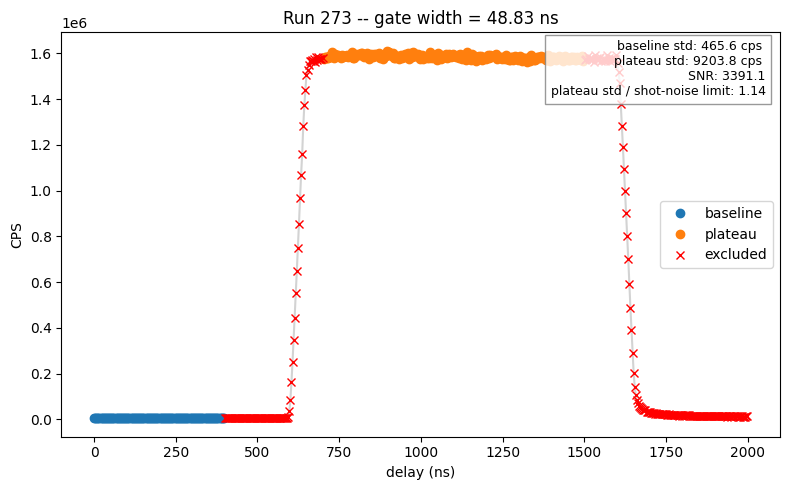

baseline std: 465.6 cps  plateau std: 9203.8 cps
plateau std / shot-noise limit: 1.14  (1.0 = shot-noise-limited)


In [32]:
# single source of truth for both plotting and stats
baseline_mask_pts = t < 400
plateau_mask_pts = (t > 700) & (t < 1500)
excluded_mask_pts = ~(baseline_mask_pts | plateau_mask_pts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, y, '-', color='lightgray', zorder=1)
ax.plot(t[baseline_mask_pts], y[baseline_mask_pts], 'o', color='tab:blue', label='baseline')
ax.plot(t[plateau_mask_pts], y[plateau_mask_pts], 'o', color='tab:orange', label='plateau')
ax.plot(t[excluded_mask_pts], y[excluded_mask_pts], 'x', color='red', label='excluded')
ax.legend(loc='center right')
ax.set_xlabel('delay (ns)')
ax.set_ylabel('CPS')
ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')

baseline_mean = y[baseline_mask_pts].mean()
plateau_mean = y[plateau_mask_pts].mean()
baseline_std = y[baseline_mask_pts].std()
plateau_std = y[plateau_mask_pts].std()

snr = (plateau_mean - baseline_mean) / baseline_std

counts_mean = spd_runs[run_num]["data"]["counts_mean"]
plateau_counts_mean = counts_mean[plateau_mask_pts].mean()
plateau_std_counts = counts_mean[plateau_mask_pts].std()
reps = spd_runs[run_num]["metadata"]["reps"]
shot_noise_limit = np.sqrt(plateau_counts_mean / reps)
excess_noise_ratio = plateau_std_counts / shot_noise_limit

stats_text = (f"baseline std: {baseline_std:.1f} cps \n"
              f"plateau std: {plateau_std:.1f} cps \n"
              f"SNR: {snr:.1f}\n"
              f"plateau std / shot-noise limit: {excess_noise_ratio:.2f}")
ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"baseline std: {baseline_std:.1f} cps  plateau std: {plateau_std:.1f} cps")
print(f"plateau std / shot-noise limit: {excess_noise_ratio:.2f}  (1.0 = shot-noise-limited)")

Save

In [33]:
save_dir = spd_runs[run_num]["folder"]
fig.savefig(save_dir / "SNR.png", dpi=150, bbox_inches='tight')
print(f"Saved to: {save_dir / 'SNR.png'}")

Saved to: /Volumes/hlab-nas/Data/DefectMsmts/Data/Convolution_Msmnts/20260723133544_273/SNR.png


<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Deconvolution</h4>
</div>

<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Build Kernel</h5>
</div>

In [34]:
run_num = 273
t = spd_runs[run_num]["data"]["delays_ns"]
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
gate_width = spd_runs[run_num]["metadata"]["gate_width_tns"]

dt = np.median(np.diff(t))  # actual sample spacing, ~3.26 ns
kernel_len = max(1, int(round(gate_width / dt)))  # gate width in units of samples

kernel = np.ones(kernel_len) / kernel_len  # boxcar, normalized to sum to 1

print(f"sample spacing: {dt:.3f} ns")
print(f"gate width: {gate_width:.3f} ns -> kernel length: {kernel_len} samples")

sample spacing: 3.282 ns
gate width: 48.828 ns -> kernel length: 15 samples


<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Richardson Lucy Deconvolve Function</h5>
</div>

In [13]:
def compute_rl_rise_time(estimate, t, plateau_window=(700, 900), rise_window=(550, 750)):
    baseline_level = estimate[(t > 100) & (t < 500)].mean()
    plateau_level = estimate[(t > plateau_window[0]) & (t < plateau_window[1])].mean()

    level_10 = baseline_level + 0.10 * (plateau_level - baseline_level)
    level_90 = baseline_level + 0.90 * (plateau_level - baseline_level)

    rise_mask = (t > rise_window[0]) & (t < rise_window[1])
    t_rise = t[rise_mask]
    signal_rise = estimate[rise_mask]

    t_10 = np.interp(level_10, signal_rise, t_rise)
    t_90 = np.interp(level_90, signal_rise, t_rise)

    return t_90 - t_10, baseline_level, plateau_level

def model_step_convolved(t, t0, rise_time, baseline, plateau, t_off, fall_time):
    true_signal = baseline + (plateau - baseline) * 0.5 * (
        erf((t - t0) / rise_time) - erf((t - t_off) / fall_time)
    )
    blurred = safe_convolve_same(true_signal, kernel)
    return blurred


def richardson_lucy_v3(signal, kernel, n_iterations, floor=1e-6):
    signal_pos = np.clip(signal, a_min=floor, a_max=None)
    kernel_norm = kernel / kernel.sum()
    kernel_flipped = kernel_norm[::-1]

    estimate = np.full_like(signal_pos, signal_pos.mean())
    residuals = []
    estimates_by_iter = {}

    for i in range(1, n_iterations + 1):
        conv_estimate = safe_convolve_same(estimate, kernel_norm)
        conv_estimate = np.clip(conv_estimate, a_min=floor, a_max=None)

        ratio = signal_pos / conv_estimate
        correction = safe_convolve_same(ratio, kernel_flipped)
        estimate = estimate * correction

        reblurred = safe_convolve_same(estimate, kernel_norm)
        residual = np.sum((signal_pos - reblurred) ** 2)
        residuals.append(residual)
        estimates_by_iter[i] = estimate.copy()

    return estimates_by_iter, np.array(residuals)

def find_discrepancy_stopping_iter(residuals, signal, reps):
    expected_noise_floor = np.sum(signal / reps)
    crossing_idx = np.argmax(residuals <= expected_noise_floor)
    if residuals[crossing_idx] <= expected_noise_floor:
        stopping_iter = crossing_idx + 1
        print(f"Discrepancy principle: stop at iteration {stopping_iter}")
    else:
        stopping_iter = len(residuals)
        print(f"Never reaches expected noise floor within {stopping_iter} iterations tested")
    return stopping_iter, expected_noise_floor

def safe_convolve_same(signal, kernel):
    """
    Same as np.convolve(signal, kernel, mode='same'), but pads with the
    signal's own edge values instead of zeros -- prevents artificial
    pull-to-zero at the boundaries, especially important for wide kernels.
    """
    pad_width = len(kernel) // 2
    padded = np.pad(signal, pad_width, mode='edge')
    result = np.convolve(padded, kernel, mode='same')
    return result[pad_width:pad_width + len(signal)]

Check on synthetic data

gate width=130ns, reps=300000: stopping iteration=22
gate width=80ns, reps=500000: stopping iteration=4
gate width=40ns, reps=1000000: stopping iteration=3


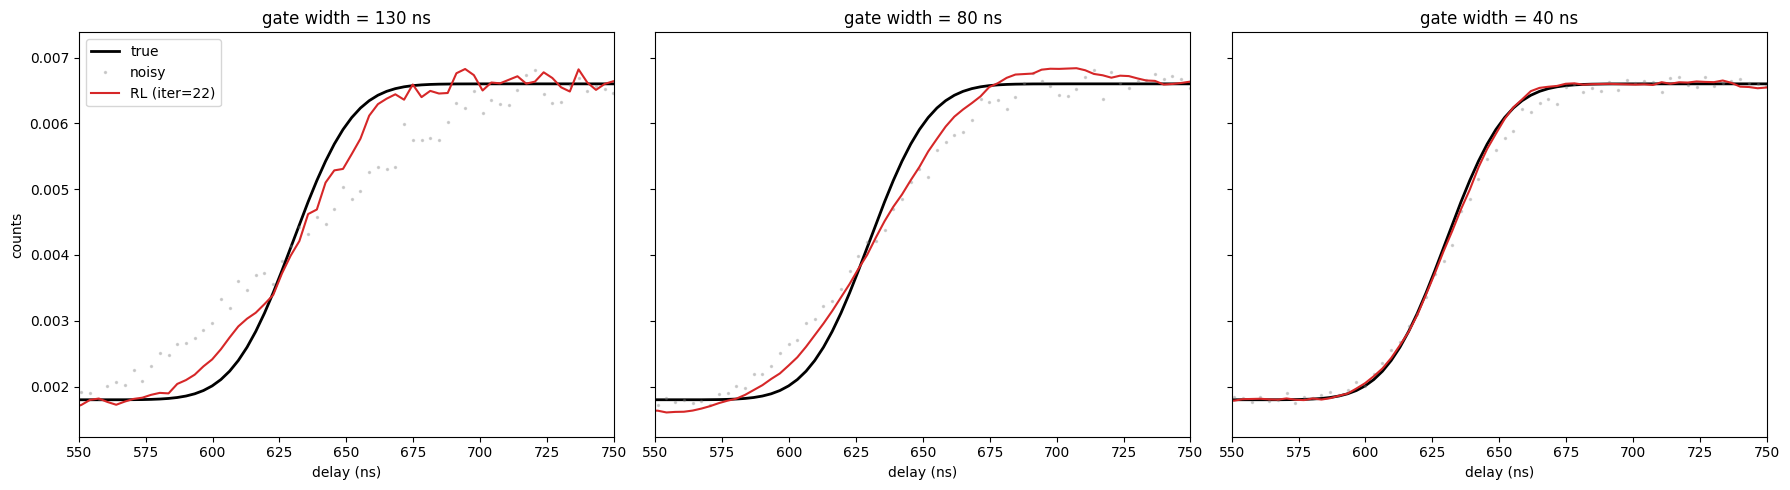

In [9]:
gate_widths_to_validate = [130, 80, 40]
reps_for_gate = {130: 300000, 80: 500000, 40: 1000000}  # scaled ~ 1/gate_width, anchored to your 1M/39ns case

dt = 3.26
t_synth = np.arange(0, 2000, dt)

t0_synth, rise_time_synth = 630, 25
baseline_synth, plateau_synth = 0.0018, 0.0066
t_off_synth, fall_time_synth = 1620, 25

true_signal = baseline_synth + (plateau_synth - baseline_synth) * 0.5 * (
    erf((t_synth - t0_synth) / rise_time_synth) - erf((t_synth - t_off_synth) / fall_time_synth)
)


fig, axes = plt.subplots(1, len(gate_widths_to_validate), figsize=(18, 5), sharey=True)

for ax, gw in zip(axes, gate_widths_to_validate):
    kernel_len = max(1, int(round(gw / dt)))
    kernel_gw = np.ones(kernel_len) / kernel_len

    blurred = safe_convolve_same(true_signal, kernel_gw)

    reps_gw = reps_for_gate[gw]
    noisy = np.random.poisson(np.clip(blurred, 0, None) * reps_gw) / reps_gw

    estimates_gw, residuals_gw = richardson_lucy_v3(noisy, kernel_gw, n_iterations=200)

    expected_noise_floor = np.sum(noisy / reps_gw)
    crossing_idx = np.argmax(residuals_gw <= expected_noise_floor)
    if residuals_gw[crossing_idx] <= expected_noise_floor:
        stop_iter = crossing_idx + 1
    else:
        stop_iter = len(residuals_gw)  # fallback if it never crosses within tested range

    best_est = estimates_gw[stop_iter]

    ax.plot(t_synth, true_signal, color='black', label='true', linewidth=2)
    ax.plot(t_synth, noisy, '.', color='gray', alpha=0.3, label='noisy', markersize=3)
    ax.plot(t_synth, best_est, color='tab:red', label=f'RL (iter={stop_iter})')
    ax.set_xlim(550, 750)
    ax.set_title(f'gate width = {gw} ns')
    ax.set_xlabel('delay (ns)')

    print(f"gate width={gw}ns, reps={reps_gw}: stopping iteration={stop_iter}")

axes[0].legend()
axes[0].set_ylabel('counts')
plt.tight_layout()
plt.show()

<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Check Iteration to Minimize Residual</h5>
</div>

Discrepancy principle: stop at iteration 13


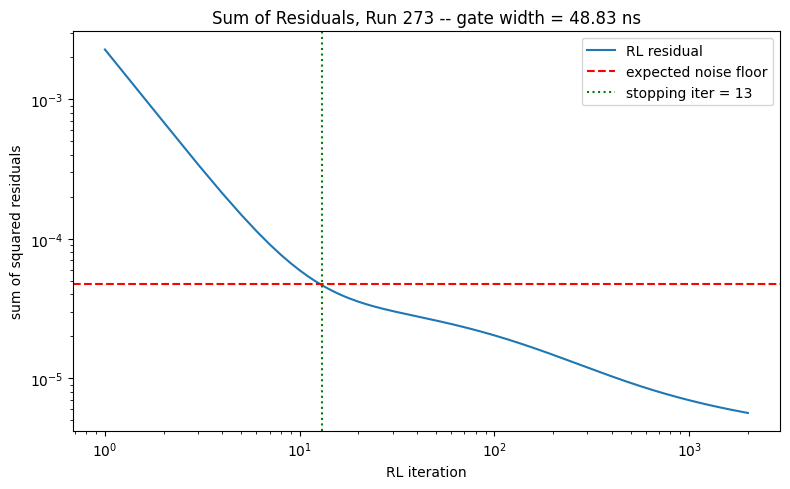

In [35]:
reps = spd_runs[run_num]["metadata"]["reps"]

estimates_real, residuals_real = richardson_lucy_v3(counts_mean, kernel, n_iterations=2000)

stop_iter, expected_noise_floor_real = find_discrepancy_stopping_iter(
    residuals_real, counts_mean, reps
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(residuals_real) + 1), residuals_real, label='RL residual')
ax.axhline(expected_noise_floor_real, color='red', linestyle='--', label='expected noise floor')
ax.axvline(stop_iter, color='green', linestyle=':', label=f'stopping iter = {stop_iter}')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('RL iteration')
ax.set_ylabel('sum of squared residuals')
ax.legend()
ax.set_title(f'Sum of Residuals, Run {run_num} -- gate width = {gate_width:.2f} ns')
plt.tight_layout()
plt.show()

best_estimate = estimates_real[stop_iter]

Save

In [36]:
save_dir = spd_runs[run_num]["folder"]
fig.savefig(save_dir / "Residuals.png", dpi=150, bbox_inches='tight')
print(f"Saved to: {save_dir / 'Residuals.png'}")

Saved to: /Volumes/hlab-nas/Data/DefectMsmts/Data/Convolution_Msmnts/20260723133544_273/Residuals.png


<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Plot Recovered Signal</h5>
</div>

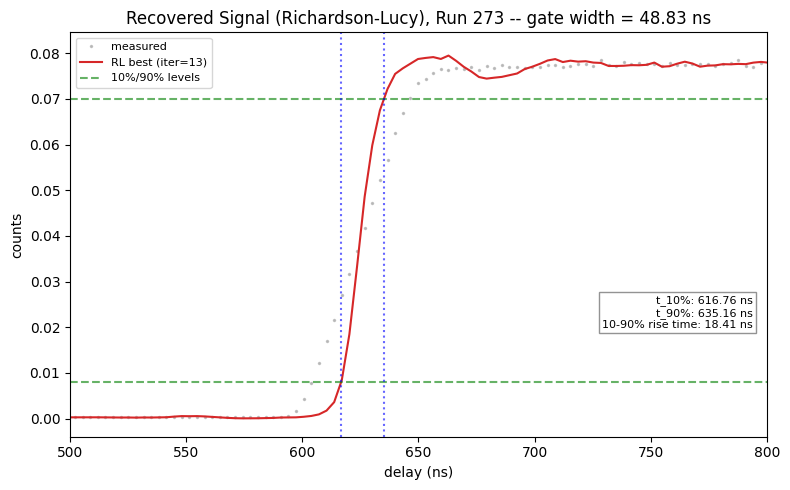

In [37]:
best_estimate = estimates_real[stop_iter]
rl_rise_time, baseline_lvl, plateau_lvl = compute_rl_rise_time(best_estimate, t)

level_10 = baseline_lvl + 0.10 * (plateau_lvl - baseline_lvl)
level_90 = baseline_lvl + 0.90 * (plateau_lvl - baseline_lvl)

rise_mask = (t > 550) & (t < 750)
t_rise = t[rise_mask]
signal_rise = best_estimate[rise_mask]
t_10 = np.interp(level_10, signal_rise, t_rise)
t_90 = np.interp(level_90, signal_rise, t_rise)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, counts_mean, '.', color='gray', alpha=0.4, label='measured', markersize=3)
ax.plot(t, best_estimate, color='tab:red', label=f'RL best (iter={stop_iter})')
ax.axhline(level_10, color='green', linestyle='--', alpha=0.6, label='10%/90% levels')
ax.axhline(level_90, color='green', linestyle='--', alpha=0.6)
ax.axvline(t_10, color='blue', linestyle=':', alpha=0.6)
ax.axvline(t_90, color='blue', linestyle=':', alpha=0.6)
ax.set_xlim(500, 800)
ax.legend(loc='upper left', fontsize=8)

stats_text = (f"t_10%: {t_10:.2f} ns\n"
              f"t_90%: {t_90:.2f} ns\n"
              f"10-90% rise time: {rl_rise_time:.2f} ns")
ax.text(0.98, 0.35, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=8,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, pad=2))

ax.set_xlabel('delay (ns)')
ax.set_ylabel('counts')
ax.set_title(f'Recovered Signal (Richardson-Lucy), Run {run_num} -- gate width = {gate_width:.2f} ns')
plt.tight_layout()
plt.show()

Save

In [27]:
save_dir = spd_runs[run_num]["folder"]
fig.savefig(save_dir / "Recovered_Signal.png", dpi=150, bbox_inches='tight')
print(f"Saved to: {save_dir / 'Recovered_Signal.png'}")

Saved to: /Volumes/hlab-nas/Data/DefectMsmts/Data/Convolution_Msmnts/20260723001353_271/Recovered_Signal.png
